# Inference for PDB DR using PDEformer-2
PDB DR is not part of PDEFoundry, which PDEformer is pretrained on.

# Load model

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from mindspore import context
from src import load_config, get_model, PDENodesCollector, sample_grf
from src.inference import infer_plot_2d, x_fenc, y_fenc, interp_fenc, inference_cartesian, inference_pde

# basic setting
context.set_context(mode=context.GRAPH_MODE, device_target="CPU")
config = load_config("configs/inference/model-M.yaml")
model = get_model(config)

[WARNING] ME(44168:8304385664,MainProcess):2026-05-26-17:00:04.101.000 [mindspore/context.py:1334] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


# Extracting data attributes

As per dataset_overview.md, 'data' has 2 channels corresponding to the 2 variables of PDB DR.

The mean and standard deviation are calculated here to serve as reference, but they are not used in any way later on.

In [26]:
import h5py
import numpy as np

pdb_gsdr = '/Volumes/T7/PDEBench/2D/diffusion-reaction/dr_sliced_0_99.h5'

with h5py.File(pdb_gsdr, 'r') as f:
    print(f['0000'].keys())
    print(f['0000'].attrs.keys())
    print(f['0000'].attrs['config'])
    print(f['0000']['grid']['x'])
    print(f['0000']['grid']['y'])
    print(f['0000']['grid']['t'])
    print(f['0000']['data'])
    reference = f['0000']['data'][:]
    reference_A = f['0000']['data'][:,:,:,0]
    reference_B = f['0000']['data'][:,:,:,1]

    print()
    global_mean = np.mean(reference)
    global_std = np.std(reference)
    print(global_mean, global_std)

    print()
    channelA_mean = np.mean(reference_A)
    channelA_std = np.std(reference_A)
    print(channelA_mean, channelA_std)

    print()
    channelB_mean = np.mean(reference_B)
    channelB_std = np.std(reference_B)
    print(channelB_mean, channelB_std)

    print(np.max(f['0000']['data'][:,:,:,0]))
    print(np.min(f['0000']['data'][:,:,:,0]))

    x_coord = f['0000']['grid']['x'][:]    # (128,)
    y_coord = f['0000']['grid']['y'][:]
    t_coord = f['0000']['grid']['t'][:]


<KeysViewHDF5 ['data', 'grid']>
<KeysViewHDF5 ['config']>
work_dir: ${hydra:runtime.cwd}
data_dir: ${work_dir}/data/
output_path: /pfs/work7/workspace/scratch/st_ac131224-pde_test/data//diff-react/train_0000.h5
name: null
sim:
  Du: 0.001
  Dv: 0.005
  k: 0.005
  t: 5
  tdim: 501
  x_left: -1.0
  x_right: 1.0
  xdim: 512
  y_bottom: -1.0
  y_top: 1.0
  ydim: 512
  'n': 1
  seed: 0
default_mode: true

<HDF5 dataset "x": shape (128,), type "<f4">
<HDF5 dataset "y": shape (128,), type "<f4">
<HDF5 dataset "t": shape (101,), type "<f4">
<HDF5 dataset "data": shape (101, 128, 128, 2), type "<f4">

-0.029704755 0.1313514

-0.036573187 0.14610168

-0.02283634 0.11430799
4.2417717
-3.5104098


# Temporal resampling of data

PDB DR dt=0.05, but PDEFoundry DCR/MVDCR dt=0.01.

To account for this,
1) Find start and end times for PDB DR dataset, which is [0,501], since t $\in$[0,5], with 101 timesteps.
2) Calculate total number of timesteps needed to cover [0,501], but with dt=0.01 now.
3) Interpolate accordingly.

In [48]:
import h5py
import numpy as np
from scipy.interpolate import interp1d

pdb_gsdr = '/Volumes/T7/PDEBench/2D/diffusion-reaction/dr_sliced_0_99.h5'

with h5py.File(pdb_gsdr, 'r') as f:
    reference = f['0000']['data'][:]       # Shape: (T, X, Y, C)
    x_coord = f['0000']['grid']['x'][:]
    y_coord = f['0000']['grid']['y'][:]
    t_coord = f['0000']['grid']['t'][:]    # Shape: (T,)

    print(f"Original data shape: {reference.shape}")
    print(f"Original dt: {t_coord[1] - t_coord[0]:.3f}")

    #Temporal resampling: from dt=0.05 -> dt=0.01
    model_dt = 0.01

    t_start = t_coord.min()
    t_end = t_coord.max()
    num_new_steps = int(np.round((t_end - t_start) / model_dt)) + 1
    print(t_start, t_end, num_new_steps)

    t_new = np.linspace(t_start, t_end, num_new_steps)
    interpolator = interp1d(t_coord, reference, axis=0, kind='cubic')

    resampled_reference = interpolator(t_new)

    print(f"Resampled data shape: {resampled_reference.shape}")
    print(f"New dt: {t_new[1] - t_new[0]:.3f}")

    reference_A = resampled_reference[:,:,:,0]
    reference_B = resampled_reference[:,:,:,1]
    reference = np.stack([reference_A, reference_B], axis=-1)
    print(reference.shape)


Original data shape: (101, 128, 128, 2)
Original dt: 0.050
0.0 5.0 501
Resampled data shape: (501, 128, 128, 2)
New dt: 0.010
(501, 128, 128, 2)


# Generating the DAG

Coefficients Du/Dv/k are taken from the data attributes.

For the ICs, we just take t=0 for both u and v of 'data'.

For the BC, given that PDB DR employs a no-flow Neumann BC, I used PDEformer's notebook as reference, which uses signed distance function (SDF) where x,y $\in$[0,1].

PDB DR's equations are taken from PDEBench's paper.

From PDEFormer's notebook:

#### Specification of Complex Domains and Boundary Conditions

- For non-periodic boundaries, it is necessary to explicitly specify the domain of the unknown field variables and the location of the boundaries.
- Both the domain and boundary locations can be represented using Signed Distance Functions (SDF). The SDF of a set $S$ is defined as
  $$\mathrm{SDF}_S(r) = d(r,S) - d(r,S^c),$$
  where $r = (x,y)$. This function is negative inside $S$, positive outside $S$, and zero on the boundary of $S$.
- If the domain remains a rectangular region with periodic boundaries along one axis, the SDF should only account for non-periodic boundaries, ignoring the periodic ones during computation.

[('sdf0', 'sdf'), ('uf1', 'uf', 'sdf0'), ('uf2', 'uf', 'sdf0'), ('ic3', 'ic', 'uf1'), ('ic4', 'ic', 'uf2'), ('dx5', 'dx', 'uf1'), ('dx6', 'dx', 'sdf0'), ('mul7', 'mul', 'dx5', 'dx6'), ('dy8', 'dy', 'uf1'), ('dy9', 'dy', 'sdf0'), ('mul10', 'mul', 'dy8', 'dy9'), ('add11', 'add', 'mul7', 'mul10'), ('eq012', 'eq0', 'add11', 'sdf0'), ('dx13', 'dx', 'uf2'), ('mul14', 'mul', 'dx13', 'dx6'), ('dy15', 'dy', 'uf2'), ('mul16', 'mul', 'dy15', 'dy9'), ('add17', 'add', 'mul14', 'mul16'), ('eq018', 'eq0', 'add17', 'sdf0'), ('coef19', 'coef'), ('coef20', 'coef'), ('coef21', 'coef'), ('dt22', 'dt', 'uf1'), ('dx23', 'dx', 'dx5'), ('mul24', 'mul', 'coef19', 'dx23'), ('neg25', 'neg', 'mul24'), ('dy26', 'dy', 'dy8'), ('mul27', 'mul', 'coef19', 'dy26'), ('neg28', 'neg', 'mul27'), ('neg29', 'neg', 'uf1'), ('square30', 'square', 'uf1'), ('mul31', 'mul', 'uf1', 'square30'), ('add32', 'add', 'dt22', 'neg25', 'neg28', 'neg29', 'mul31', 'coef21', 'uf2'), ('eq033', 'eq0', 'add32'), ('dt34', 'dt', 'uf2'), ('dx35', 

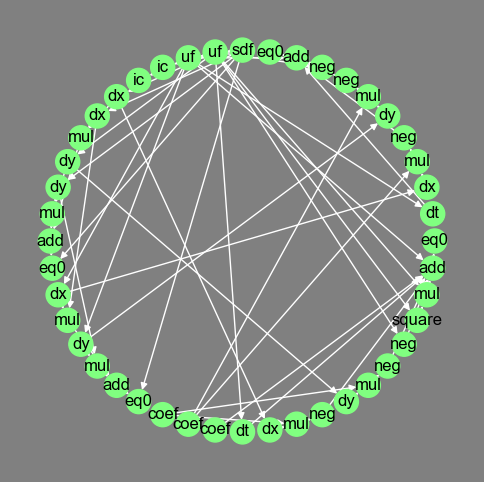

In [90]:
pde = PDENodesCollector(dim=2)

# xx, yy = np.meshgrid(x_coord, y_coord, indexing="ij")
x_plot, y_plot = np.meshgrid(np.linspace(0, 1, 129)[:-1], np.linspace(0, 1, 129)[:-1], indexing="ij")

#SDF for new_domain in pde_dag.py
sdf_x = np.abs(x_plot-0.5) - 0.5
sdf_y = np.abs(y_plot-0.5) - 0.5
sdf_box = np.maximum(sdf_x, sdf_y)

# Combined box SDF: negative inside (where all edges are negative)
domain = pde.new_domain(sdf_box, x=x_plot, y=y_plot)
u = pde.new_uf(domain)
v = pde.new_uf(domain)

#IC
u_ic = reference[0, :, :,0].astype(np.float32)  # activator at t=0
v_ic = reference[0, :, :, 1].astype(np.float32)  # inhibitor at t=0
pde.set_ic(u, u_ic, x=x_plot, y=y_plot)
pde.set_ic(v, v_ic, x=x_plot, y=y_plot)

pde.bc_sum_eq0(domain, *pde.dn_sum_list(u, domain))
pde.bc_sum_eq0(domain, *pde.dn_sum_list(v, domain))

#Params
Du = pde.new_coef(1e-3)
Dv = pde.new_coef(5e-3)
k  = pde.new_coef(5e-3)

# du/dt = Du*(u_xx + u_yy) + u - u^3 - k - v
pde.sum_eq0(u.dt,
            pde.neg(pde.prod(Du, u.dx.dx)),
            pde.neg(pde.prod(Du, u.dy.dy)),
            pde.neg(u),
            u.cubic,
            k,
            v)

# dv/dt = Dv*(v_xx + v_yy) + u - v
pde.sum_eq0(v.dt,
            pde.neg(pde.prod(Dv, v.dx.dx)),
            pde.neg(pde.prod(Dv, v.dy.dy)),
            pde.neg(u),
            v)

pde_dag = pde.gen_dag(config)

print(pde.node_list)
pde_dag.plot(hide='aux')

# Inference and plotting

[WARNING] ANALYZER(44168,0x1eefade80,Python):2026-05-26-17:00:15.658.955 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1608] ClearIsolatedNodes] Some side effect nodes were eliminated by mistake. The node is:@20302_src_cell_pdeformer_pdeformer_PDEEncoder_construct_1109:_{[0]: ValueNode<FuncGraph> 22863__tuple_getitem_by_number_1110, [1]: ValueNode<ValueTuple> (1, 6, 16384, 5), [2]: ValueNode<Int64Imm> 3}
[WARNING] ANALYZER(44168,0x1eefade80,Python):2026-05-26-17:00:15.659.140 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1608] ClearIsolatedNodes] Some side effect nodes were eliminated by mistake. The node is:@22996_src_cell_pdeformer_function_encoder_Conv2dFuncEncoderV3_construct_1111:_{[0]: ValueNode<FuncGraph> 23156__tuple_getitem_by_number_1112, [1]: ValueNode<ValueTuple> (6, 16384, 5), [2]: ValueNode<Int64Imm> 1}
[WARNING] ANALYZER(44168,0x1eefade80,Python):2026-05-26-17:00:15.660.156 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1

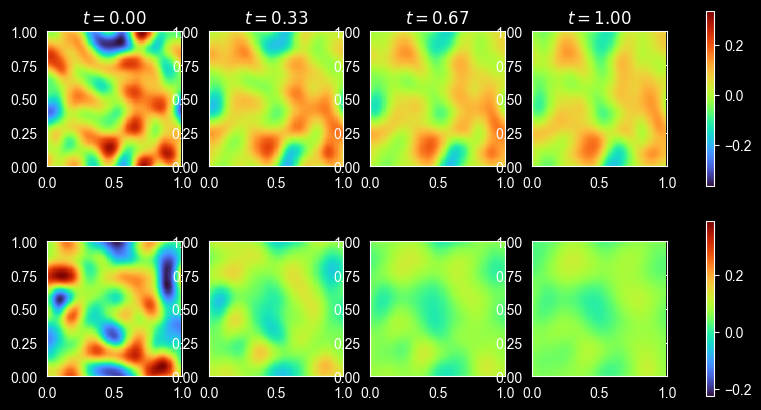

In [92]:
x_plot, y_plot = np.meshgrid(np.linspace(0, 1, 129)[:-1], np.linspace(0, 1, 129)[:-1], indexing="ij")
snap_t = np.array([0.0,0.33,0.67,1.0])

pred_plot4 = infer_plot_2d(model, pde_dag, x_plot, y_plot, snap_t=snap_t)

# Custom Plotting block
To plot the pred and ground truth for each of the 2 variables.

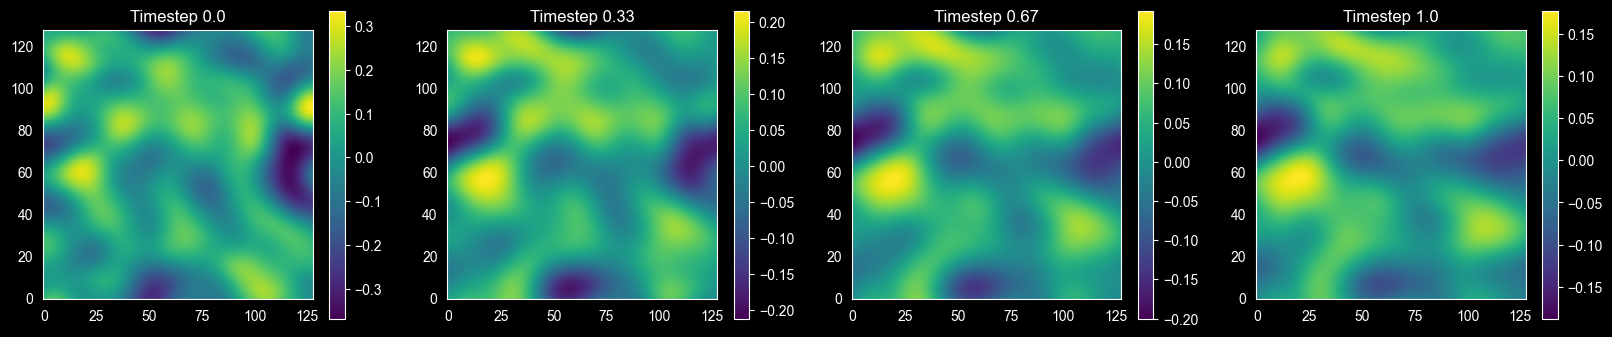

[0, 165, 335, 500]


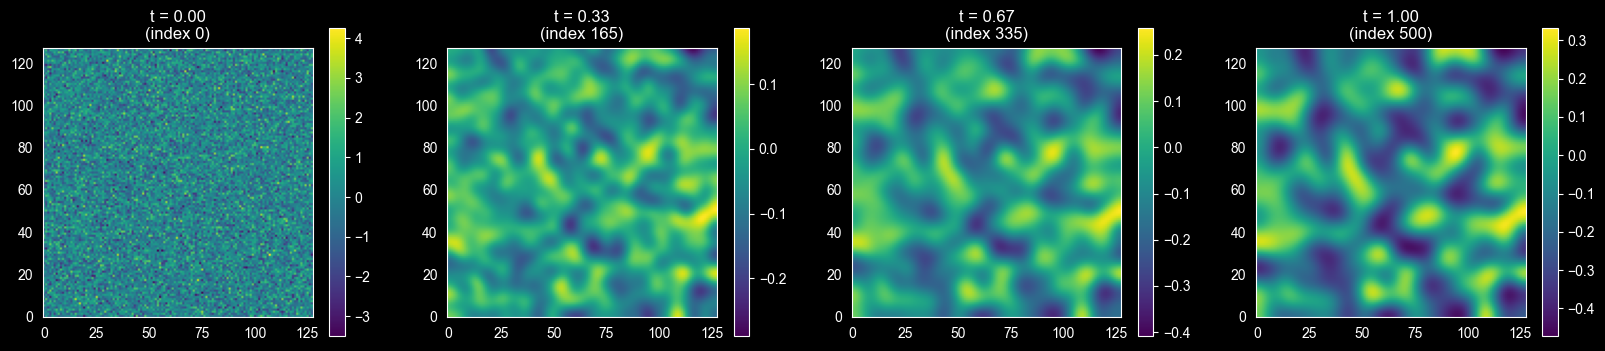

In [98]:
#Channel 0 (u) for data plot
import matplotlib.pyplot as plt

n_timesteps = 4
fig, axes = plt.subplots(1, n_timesteps, figsize=(5 * n_timesteps, 4))
for t in range(n_timesteps):
    im = axes[t].imshow(
        pred[t, :, :, 0],
        cmap='viridis',
        origin='lower'
    )

    axes[t].set_title(f'Timestep {snap_t[t]}')
    axes[t].grid(False)

    fig.colorbar(im, ax=axes[t])
plt.show()

# Convert normalized times to indices
indices = [int(t * (501 - 1)) for t in snap_t]
print(indices)

fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 4))

for ax, idx, t in zip(axes, indices, snap_t):
    im = ax.imshow(
        reference[idx, :, :, 0],
        cmap='viridis',
        origin='lower'
    )

    ax.set_title(f't = {t:.2f}\n(index {idx})')
    ax.grid(False)

    fig.colorbar(im, ax=ax)
plt.show()

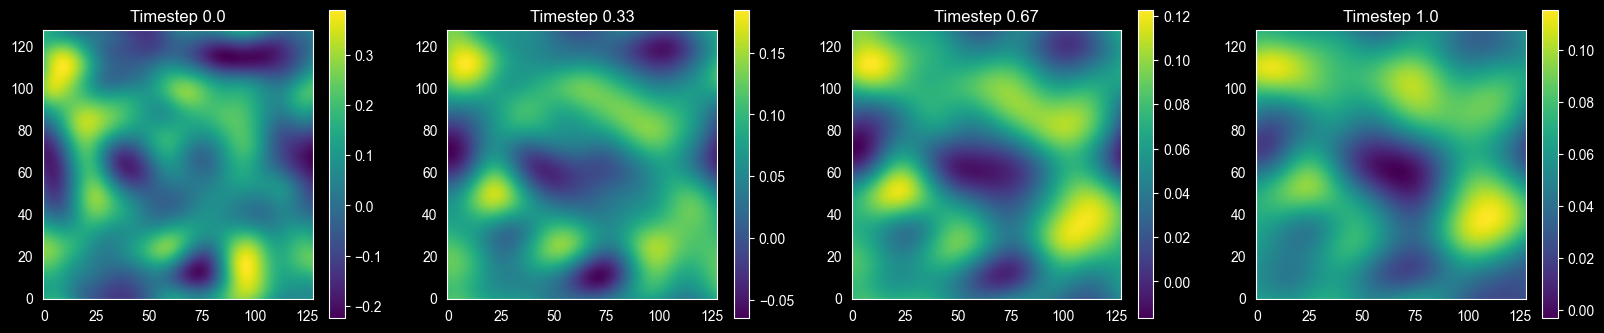

[0, 165, 335, 500]


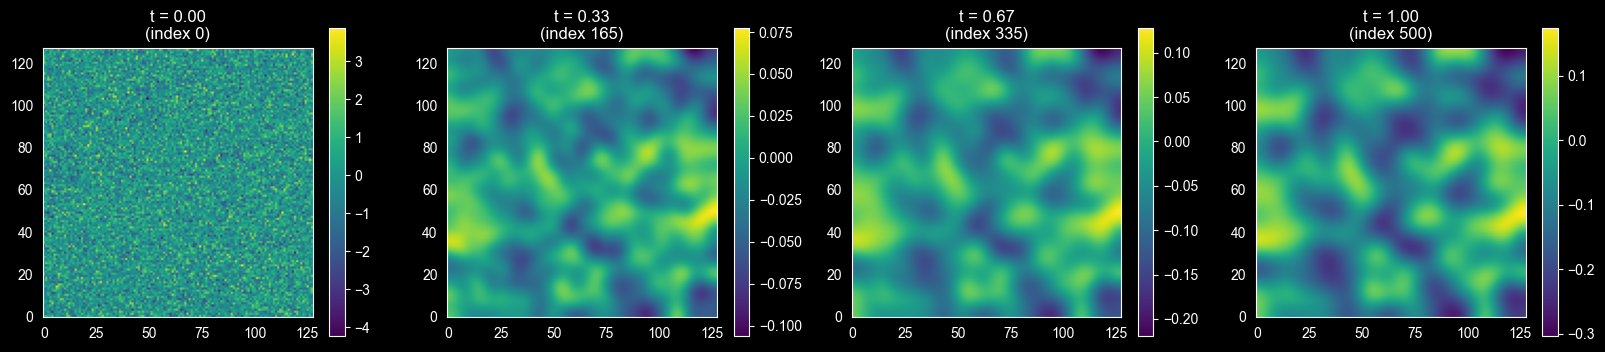

In [100]:
#Channel 1(v) for data plot
import matplotlib.pyplot as plt

n_timesteps = 4
fig, axes = plt.subplots(1, n_timesteps, figsize=(5 * n_timesteps, 4))
for t in range(n_timesteps):
    im = axes[t].imshow(
        pred[t, :, :, 1],
        cmap='viridis',
        origin='lower'
    )

    axes[t].set_title(f'Timestep {snap_t[t]}')
    axes[t].grid(False)

    fig.colorbar(im, ax=axes[t])
plt.show()

# Convert normalized times to indices
indices = [int(t * (501 - 1)) for t in snap_t]
print(indices)

fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 4))

for ax, idx, t in zip(axes, indices, snap_t):
    im = ax.imshow(
        reference[idx, :, :, 1],
        cmap='viridis',
        origin='lower'
    )

    ax.set_title(f't = {t:.2f}\n(index {idx})')
    ax.grid(False)

    fig.colorbar(im, ax=ax)
plt.show()